In [314]:
import os
import numpy as np
import re
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

In [315]:
DATA_PATH = "../../data/output_data/"
FIGURES_PATH = "../../data/figures/"
dataset = "hgsoc_new"
# Tools: BAMixChecker, CrossCheckFingerprints, HYSYS, NGSCheckmate, Vireo

In [324]:
def all_samples_matrix_viz(matrix_df, tool, dataset, save_fig=False):

    # Visualize ALL samples against ALL samples
    extreme_point = max(
        abs(matrix_df.min().min()), abs(matrix_df.max().max())
    )

    fig, ax = plt.subplots(figsize=(12, 12))
    if tool == "CrosscheckFingerprints":
        cmap = plt.get_cmap("RdBu")
        cmap.set_bad(color="lightgrey")
        cax = ax.matshow(matrix_df, cmap=cmap, vmin= -extreme_point, vmax= extreme_point)
    else:
        cmap = plt.get_cmap("Oranges")
        cmap.set_bad(color="lightgrey")
        cax = ax.matshow(matrix_df, cmap=cmap)

    ax.set_xticks(np.arange(len(matrix_df.columns)))
    ax.set_yticks(np.arange(len(matrix_df.index)))
    ax.set_xticklabels(matrix_df.columns, rotation=45, ha="left", fontdict={"fontsize": 8})
    ax.set_yticklabels(matrix_df.index, fontdict={"fontsize": 8})
    ax.xaxis.set_label_position("top")
    ax.set_title(f"{tool} Similarity Matrix", pad=20)

    fig.colorbar(cax, fraction=0.046, pad=0.04, shrink=0.5)

    if save_fig:
        fig.savefig(
            os.path.join(
                FIGURES_PATH,
                f"{dataset}_{tool}_all_samples_similarity_matrix.png",
            ),
            bbox_inches="tight",
            dpi=300,
        )
        fig.savefig(
            os.path.join(
                FIGURES_PATH,
                f"{dataset}_{tool}_all_samples_similarity_matrix.pdf",
            ),
            bbox_inches="tight",
            dpi=300,
        )

    return

In [317]:
def bulk_vs_singlecell_matrix_viz(matrix_df, tool, dataset, save_fig=False):

    # Visualize bulk against single-cell samples
    sub_matrix = matrix_df[
        [col for col in matrix_df.columns if "polyA" in col]
    ]
    sub_matrix = sub_matrix.loc[
        [idx for idx in sub_matrix.index if "ribo" in idx]
    ]

    extreme_point = max(
        abs(sub_matrix.min().min()), abs(sub_matrix.max().max())
    )

    fig, ax = plt.subplots(figsize=(8, 8))
    if tool == "CrosscheckFingerprints":
        cmap = plt.get_cmap("RdBu")
        cmap.set_bad(color="lightgrey")
        cax = ax.matshow(sub_matrix, cmap=cmap, vmin= -extreme_point, vmax= extreme_point)
    else:
        cmap = plt.get_cmap("Oranges")
        cmap.set_bad(color="lightgrey")
        cax = ax.matshow(sub_matrix, cmap=cmap)

    ax.set_xticks(np.arange(len(sub_matrix.columns)))
    ax.set_yticks(np.arange(len(sub_matrix.index)))
    ax.set_xticklabels(sub_matrix.columns, rotation=45, ha="left")
    ax.set_yticklabels(sub_matrix.index)
    ax.xaxis.set_label_position("top")
    ax.set_xlabel("Single-cell samples")
    ax.set_ylabel("Bulk samples")
    ax.set_title(f"{tool} Bulk vs Single-cell Similarity Matrix", pad=20)

    fig.colorbar(cax, fraction=0.046, pad=0.04, shrink=0.5)

    if save_fig:
        fig.savefig(
            os.path.join(
                FIGURES_PATH,
                f"{dataset}_{tool}_bulk_vs_singlecell_similarity_matrix.png",
            ),
            bbox_inches="tight",
            dpi=300,
        )
        fig.savefig(
            os.path.join(
                FIGURES_PATH,
                f"{dataset}_{tool}_bulk_vs_singlecell_similarity_matrix.pdf",
            ),
            bbox_inches="tight",
            dpi=300,
        )

    return

# Vireo

In [318]:
vireo_matrix = pd.read_csv(DATA_PATH + f"vireo/{dataset}/similarity_matrix.csv", index_col=0)

In [319]:
vireo_matrix.columns = [re.sub(r"[a-zA-Z0-9]{32}_", "", col.replace(".bam", "").replace("ds.", "")) for col in vireo_matrix.columns]
vireo_matrix.index = pd.Index([re.sub(r"[a-zA-Z0-9]{32}_", "", idx.replace(".bam", "").replace("ds.", "")) for idx in vireo_matrix.index])

In [320]:
# Order rows and columns
ordered_columns = sorted(vireo_matrix.columns)
ordered_index = sorted(vireo_matrix.index)
vireo_matrix = vireo_matrix.loc[ordered_index, ordered_columns]

In [321]:
vireo_matrix.head()

,HGSOC-2018_bulk_chunk_ribo,HGSOC-2023_bulk_chunk_ribo,HGSOC-2094_bulk_chunk_ribo,HGSOC-2126_bulk_chunk_ribo,HGSOC-2129_bulk_chunk_ribo,HGSOC-2186_bulk_chunk_ribo,HGSOC-2202_bulk_chunk_ribo,HGSOC-2209_bulk_chunk_ribo,HGSOC-2216_bulk_chunk_ribo,HGSOC-2221_bulk_chunk_ribo,...,HGSOC-2423_bulk_chunk_ribo,HGSOC-2430_bulk_chunk_ribo,HGSOC-2444_bulk_chunk_ribo,HGSOC-2455_bulk_chunk_ribo,HGSOC-2460_bulk_chunk_ribo,HGSOC-2466_bulk_chunk_ribo,HGSOC-2477_bulk_chunk_ribo,HGSOC-2483_bulk_chunk_ribo,HGSOC-2507_bulk_chunk_ribo,HGSOC-2526_bulk_chunk_ribo
HGSOC-2018_bulk_diss_polyA,0.103071,0.204635,0.203054,0.200692,0.220670,0.207542,0.204564,0.211020,0.234527,0.212180,...,0.217893,0.209463,0.217643,0.204165,0.200763,0.202492,0.203262,0.205400,0.244545,0.235609
HGSOC-2023_bulk_diss_polyA,0.215611,0.125117,0.214787,0.216458,0.228222,0.217489,0.216472,0.224086,0.243762,0.222250,...,0.226032,0.224559,0.227117,0.218647,0.214007,0.216193,0.214240,0.214975,0.254510,0.247900
HGSOC-2094_bulk_diss_polyA,0.211382,0.212608,0.115995,0.212624,0.225290,0.214886,0.210940,0.222003,0.240515,0.224131,...,0.225986,0.223624,0.221707,0.213665,0.212258,0.214121,0.213638,0.214726,0.249788,0.244303
HGSOC-2126_bulk_diss_polyA,0.206125,0.211114,0.209657,0.110434,0.223372,0.209715,0.209800,0.215708,0.235711,0.218337,...,0.226559,0.217224,0.221115,0.210816,0.207252,0.209247,0.209359,0.210681,0.246910,0.237215
HGSOC-2129_bulk_diss_polyA,0.218276,0.218274,0.216142,0.217739,0.139619,0.219783,0.222435,0.224295,0.240079,0.225165,...,0.231214,0.225784,0.218249,0.219217,0.217842,0.218712,0.220422,0.222191,0.249391,0.242518


In [322]:
vireo_matrix.shape

(31, 31)

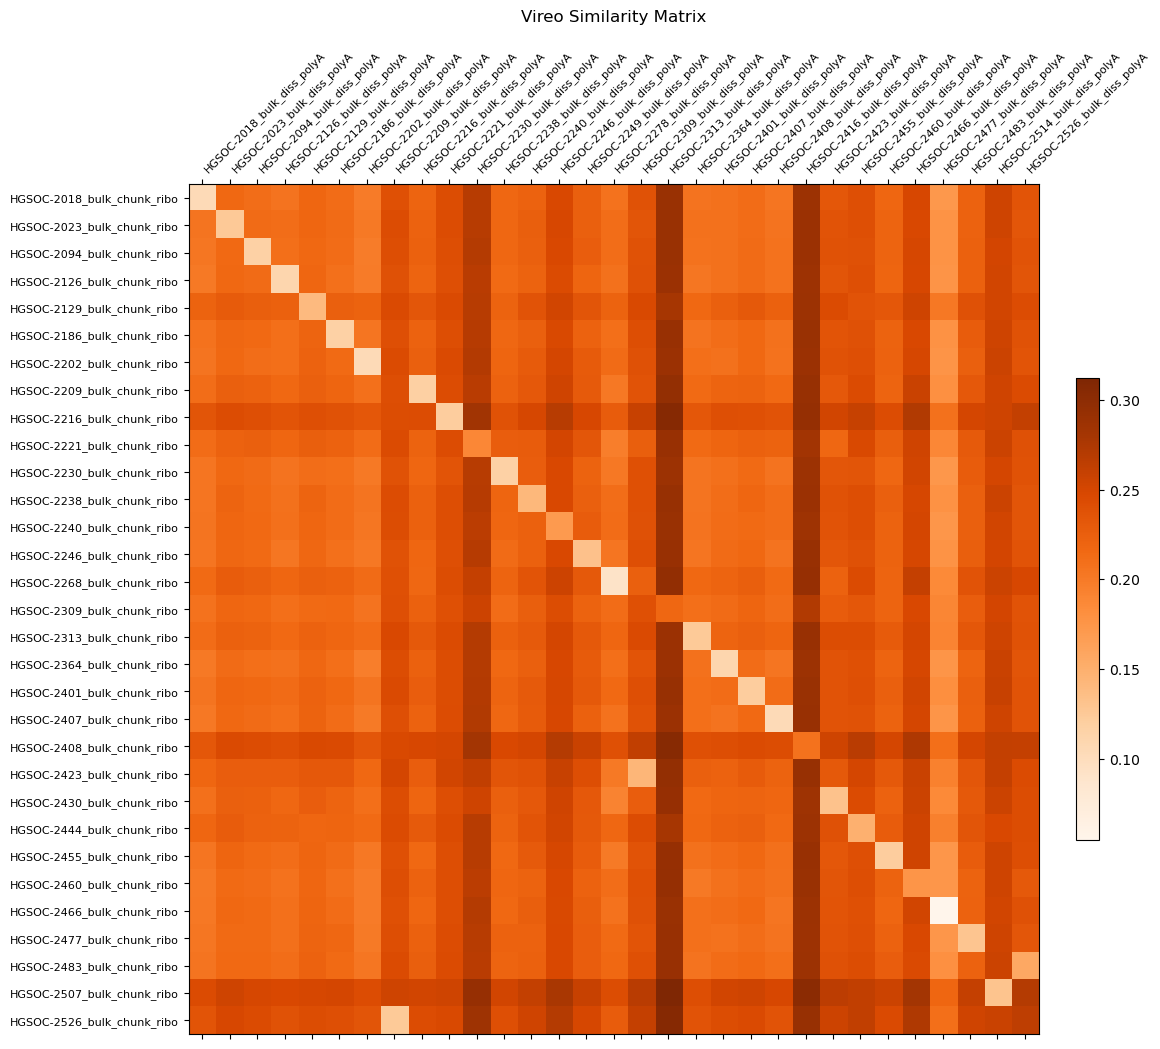

In [357]:
all_samples_matrix_viz(vireo_matrix.T, tool="Vireo", dataset=dataset, save_fig=True)

In [73]:
# bulk_vs_singlecell_matrix_viz(vireo_matrix, tool="Vireo", dataset=dataset, save_fig=False)

In [326]:
vireo_matches = pd.read_csv(DATA_PATH + f"vireo/{dataset}/matched_samples.csv", index_col=0).reset_index()

In [327]:
for col in vireo_matches.columns:
    vireo_matches[col] = [re.sub(r"[a-zA-Z0-9]{32}_", "", sample.replace(".bam", "").replace("ds.", "")) for sample in vireo_matches[col]]

vireo_matches = vireo_matches.sort_values(by=["sample_id_0"]).reset_index(drop=True)

In [328]:
vireo_matches

,sample_id_0,sample_id_1
0,HGSOC-2018_bulk_chunk_ribo,HGSOC-2018_bulk_diss_polyA
1,HGSOC-2023_bulk_chunk_ribo,HGSOC-2023_bulk_diss_polyA
2,HGSOC-2094_bulk_chunk_ribo,HGSOC-2094_bulk_diss_polyA
3,HGSOC-2126_bulk_chunk_ribo,HGSOC-2126_bulk_diss_polyA
4,HGSOC-2129_bulk_chunk_ribo,HGSOC-2129_bulk_diss_polyA
5,HGSOC-2186_bulk_chunk_ribo,HGSOC-2186_bulk_diss_polyA
6,HGSOC-2202_bulk_chunk_ribo,HGSOC-2202_bulk_diss_polyA
7,HGSOC-2209_bulk_chunk_ribo,HGSOC-2216_bulk_diss_polyA
8,HGSOC-2216_bulk_chunk_ribo,HGSOC-2221_bulk_diss_polyA
9,HGSOC-2221_bulk_chunk_ribo,HGSOC-2230_bulk_diss_polyA


# NGSCheckmate

In [329]:
ngscheckmate_df = pd.read_csv(DATA_PATH + f"ngscheckmate/{dataset}/output_all.txt", sep="\t", index_col=0, header=None)

In [330]:
ngscheckmate_dict = {
    x: 
    re.sub(r"[a-zA-Z0-9]{32}_", "", x.replace(".bam", "").replace("ds.", "").replace("_filtered_variants.vcf", "").replace("_bulk_chunk_ribo.bam", ""))
    for x in list(set(ngscheckmate_df.index) | set(ngscheckmate_df[2]))
}
ngscheckmate_df.index = ngscheckmate_df.index.map(ngscheckmate_dict)
ngscheckmate_df[2] = ngscheckmate_df[2].map(ngscheckmate_dict)
ngscheckmate_df.columns = ["Matched", "Sample", "Binary", "Correlation"]

In [331]:
ngscheckmate_df.head()

,Matched,Sample,Binary,Correlation
0,,,,
HGSOC-2018_bulk_chunk_ribo,matched,HGSOC-2018_bulk_diss_polyA,1.0,583.83
HGSOC-2018_bulk_chunk_ribo,matched,HGSOC-2023_bulk_diss_polyA,1.0,574.69
HGSOC-2018_bulk_chunk_ribo,matched,HGSOC-2023_bulk_chunk_ribo,1.0,586.09
HGSOC-2018_bulk_chunk_ribo,matched,HGSOC-2094_bulk_diss_polyA,1.0,569.97
HGSOC-2018_bulk_chunk_ribo,matched,HGSOC-2094_bulk_chunk_ribo,1.0,574.82


In [332]:
def long_df_to_matrix_ngscheckmate(df):
    matrix = pd.DataFrame()

    for x in list(df.index):
        for y in df["Sample"].values:
            corr_value = df.loc[(df.index == x) & (df["Sample"] == y), "Correlation"]
            if not corr_value.empty:
                matrix.at[y, x] = corr_value.values[0]/100
                matrix.at[x, y] = corr_value.values[0]/100

    # Order rows and columns by bulk modality and sample ID
    matrix = matrix.sort_index(
        key=lambda x: x.str.split('_').str[0]).sort_index(key=lambda x: x.str.split('_', n=1).str[1]
    )
    matrix = matrix.reindex(
        sorted(
            sorted(
                matrix.columns,
                key=lambda x: x.split('_', 1)[0]
            ),
            key=lambda x: x.split('_', 1)[1]
        )
    )
    matrix = matrix[matrix.index]

    return matrix

In [333]:
ngscheckmate_matrix = long_df_to_matrix_ngscheckmate(ngscheckmate_df)

In [334]:
ngscheckmate_matrix.head()

,HGSOC-2018_bulk_chunk_ribo,HGSOC-2023_bulk_chunk_ribo,HGSOC-2094_bulk_chunk_ribo,HGSOC-2126_bulk_chunk_ribo,HGSOC-2129_bulk_chunk_ribo,HGSOC-2186_bulk_chunk_ribo,HGSOC-2202_bulk_chunk_ribo,HGSOC-2209_bulk_chunk_ribo,HGSOC-2216_bulk_chunk_ribo,HGSOC-2221_bulk_chunk_ribo,...,HGSOC-2408_bulk_diss_polyA,HGSOC-2416_bulk_diss_polyA,HGSOC-2423_bulk_diss_polyA,HGSOC-2455_bulk_diss_polyA,HGSOC-2460_bulk_diss_polyA,HGSOC-2466_bulk_diss_polyA,HGSOC-2477_bulk_diss_polyA,HGSOC-2483_bulk_diss_polyA,HGSOC-2514_bulk_diss_polyA,HGSOC-2526_bulk_diss_polyA
HGSOC-2018_bulk_chunk_ribo,NaN,5.8609,5.7482,5.8609,5.4847,5.8609,5.8609,5.6679,5.1009,5.4775,...,5.5961,4.8619,5.6325,5.7808,5.5498,5.6222,5.5443,5.4504,5.2125,5.5722
HGSOC-2023_bulk_chunk_ribo,5.8609,NaN,5.7482,5.8776,5.4847,5.8836,5.8679,5.6679,5.1009,5.4775,...,5.5961,4.8619,5.6325,5.7808,5.5498,5.6222,5.5443,5.4504,5.2125,5.5722
HGSOC-2094_bulk_chunk_ribo,5.7482,5.7482,NaN,5.7482,5.4847,5.7482,5.7482,5.6679,5.1009,5.4775,...,5.5961,4.8619,5.6325,5.7482,5.5498,5.6222,5.5443,5.4504,5.2125,5.5722
HGSOC-2126_bulk_chunk_ribo,5.8609,5.8776,5.7482,NaN,5.4847,5.8776,5.8679,5.6679,5.1009,5.4775,...,5.5961,4.8619,5.6325,5.7808,5.5498,5.6222,5.5443,5.4504,5.2125,5.5722
HGSOC-2129_bulk_chunk_ribo,5.4847,5.4847,5.4847,5.4847,NaN,5.4847,5.4847,5.4847,5.1009,5.4775,...,5.4847,4.8619,5.4847,5.4847,5.4847,5.4847,5.4847,5.4504,5.2125,5.4847


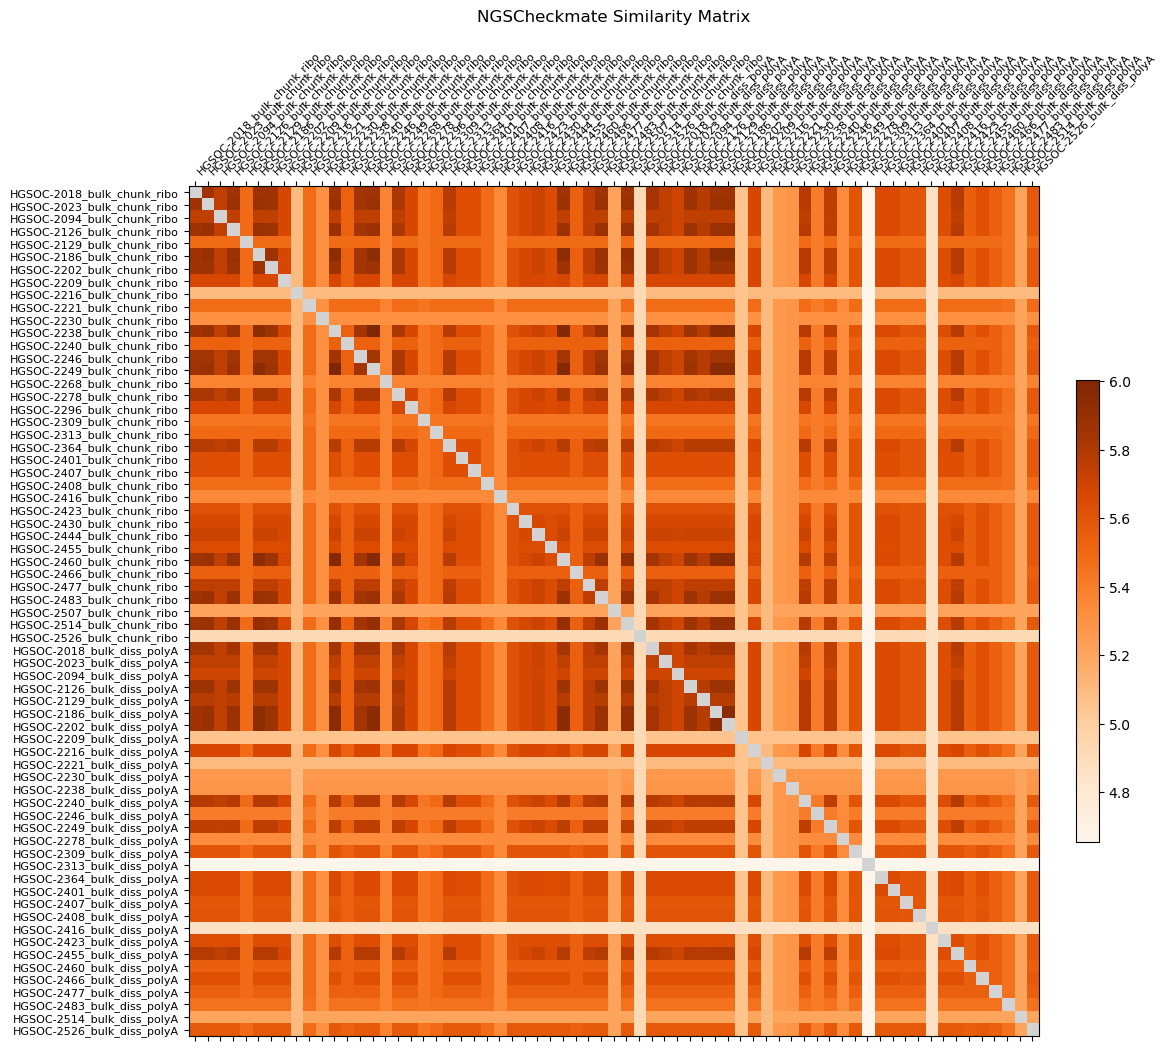

In [335]:
all_samples_matrix_viz(ngscheckmate_matrix, tool="NGSCheckmate", dataset=dataset, save_fig=True)

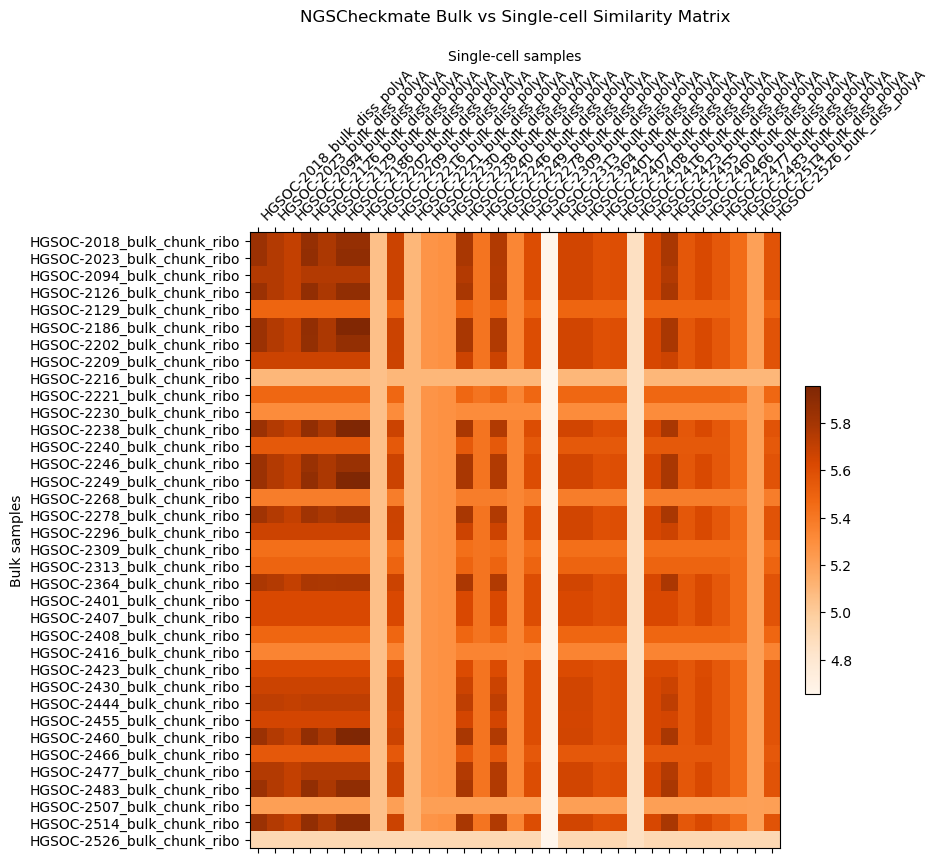

In [336]:
bulk_vs_singlecell_matrix_viz(ngscheckmate_matrix, tool="NGSCheckmate", dataset=dataset, save_fig=True)

# HYSYS

In [337]:
hysys_df = pd.read_csv(DATA_PATH + f"hysys/{dataset}/concordance_output.txt", sep="\t", index_col=0, header=None)

In [338]:
hysys_dict = {
    x: 
    re.sub(r"[a-zA-Z0-9]{32}_", "", x.replace(".bam", "").replace(f"{dataset}/", "").replace("_filtered_variants.snps", "").replace("ds.", ""))
    # x.replace("_filtered_variants.snps", "").replace(f"{dataset}/", "")
    for x in list(set(hysys_df.index) | set(hysys_df[1]))
}
hysys_df.index = hysys_df.index.map(hysys_dict)
hysys_df[1] = hysys_df[1].map(hysys_dict)
hysys_df.columns = ["Sample", "Concordance", "Size"]

In [339]:
hysys_df.head()

,Sample,Concordance,Size
0,,,
HGSOC-2018_bulk_chunk_ribo,HGSOC-2018_bulk_diss_polyA,0.209,529285
HGSOC-2018_bulk_chunk_ribo,HGSOC-2023_bulk_diss_polyA,0.126,533772
HGSOC-2018_bulk_chunk_ribo,HGSOC-2094_bulk_diss_polyA,0.135,530229
HGSOC-2018_bulk_chunk_ribo,HGSOC-2126_bulk_diss_polyA,0.151,560484
HGSOC-2018_bulk_chunk_ribo,HGSOC-2129_bulk_diss_polyA,0.145,581247


In [340]:
def long_df_to_matrix_hysys(df):
    matrix = pd.DataFrame()

    for x in list(df.index):
        for y in df["Sample"].values:
            corr_value = df.loc[(df.index == x) & (df["Sample"] == y), "Concordance"]
            if not corr_value.empty:
                matrix.at[x, y] = corr_value.values[0]

    # Order rows and columns
    matrix = matrix[matrix.columns.sort_values()]
    matrix = matrix.reindex(sorted(matrix.index))

    return matrix

In [341]:
hysys_matrix = long_df_to_matrix_hysys(hysys_df)

In [342]:
hysys_matrix.head()

,HGSOC-2018_bulk_diss_polyA,HGSOC-2023_bulk_diss_polyA,HGSOC-2094_bulk_diss_polyA,HGSOC-2126_bulk_diss_polyA,HGSOC-2129_bulk_diss_polyA,HGSOC-2186_bulk_diss_polyA,HGSOC-2202_bulk_diss_polyA,HGSOC-2209_bulk_diss_polyA,HGSOC-2216_bulk_diss_polyA,HGSOC-2221_bulk_diss_polyA,...,HGSOC-2408_bulk_diss_polyA,HGSOC-2416_bulk_diss_polyA,HGSOC-2423_bulk_diss_polyA,HGSOC-2455_bulk_diss_polyA,HGSOC-2460_bulk_diss_polyA,HGSOC-2466_bulk_diss_polyA,HGSOC-2477_bulk_diss_polyA,HGSOC-2483_bulk_diss_polyA,HGSOC-2514_bulk_diss_polyA,HGSOC-2526_bulk_diss_polyA
HGSOC-2018_bulk_chunk_ribo,0.209,0.126,0.135,0.151,0.145,0.144,0.153,0.133,0.139,0.138,...,0.143,0.063,0.133,0.130,0.130,0.091,0.203,0.107,0.124,0.096
HGSOC-2023_bulk_chunk_ribo,0.139,0.179,0.135,0.144,0.146,0.142,0.151,0.130,0.134,0.137,...,0.139,0.062,0.128,0.131,0.127,0.092,0.195,0.107,0.122,0.096
HGSOC-2094_bulk_chunk_ribo,0.145,0.129,0.195,0.150,0.150,0.146,0.156,0.136,0.140,0.141,...,0.139,0.063,0.133,0.134,0.134,0.094,0.198,0.108,0.128,0.099
HGSOC-2126_bulk_chunk_ribo,0.152,0.131,0.140,0.226,0.151,0.149,0.156,0.140,0.144,0.142,...,0.145,0.067,0.137,0.135,0.135,0.095,0.202,0.110,0.128,0.100
HGSOC-2129_bulk_chunk_ribo,0.126,0.112,0.123,0.131,0.199,0.132,0.130,0.125,0.125,0.132,...,0.122,0.061,0.118,0.123,0.117,0.083,0.159,0.095,0.114,0.090


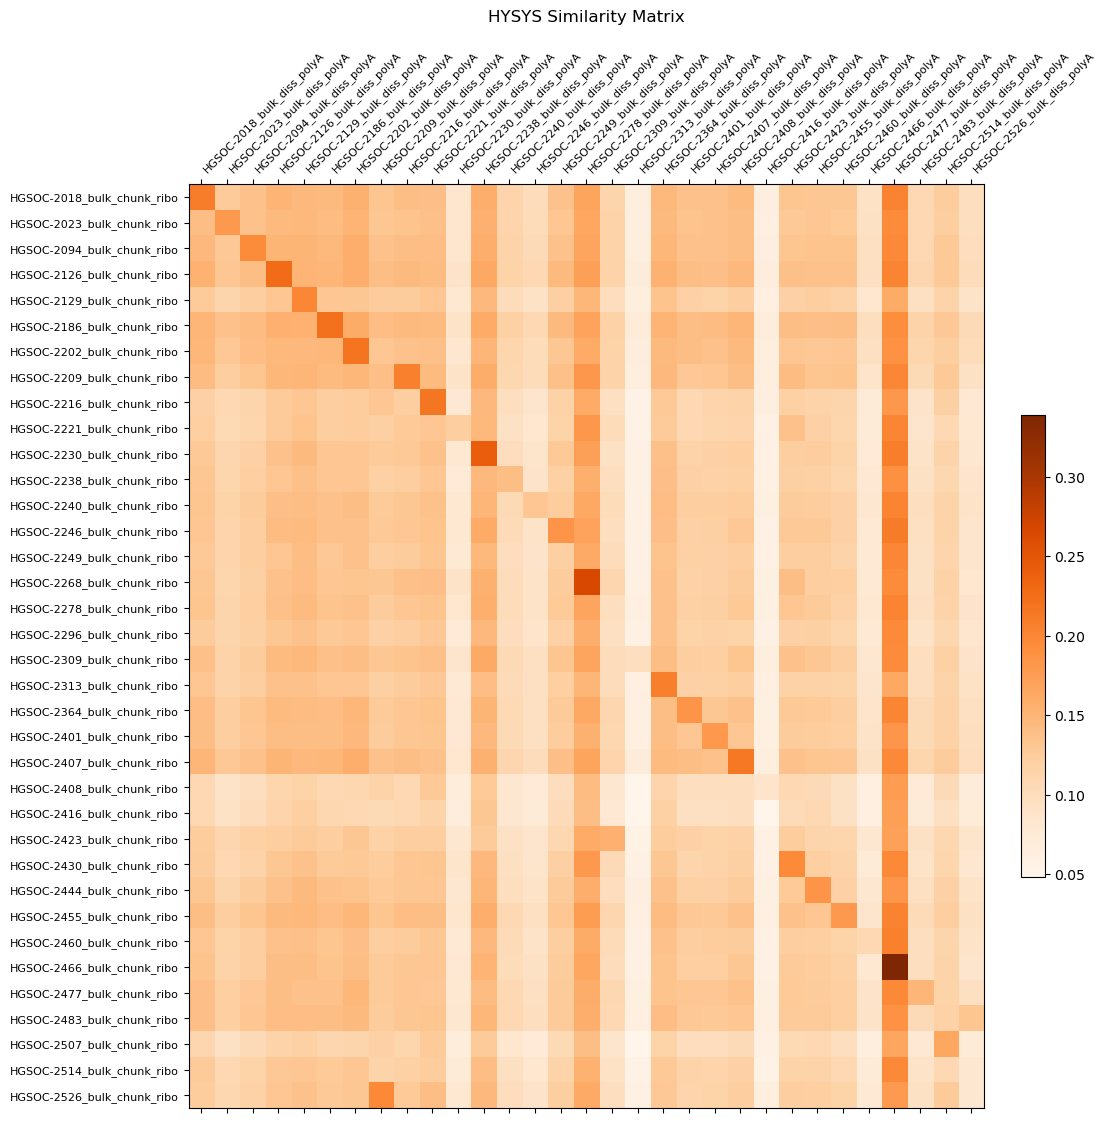

In [343]:
all_samples_matrix_viz(hysys_matrix, tool="HYSYS", dataset=dataset, save_fig=True)

In [103]:
# bulk_vs_singlecell_matrix_viz(hysys_matrix, tool="HYSYS", dataset=dataset, save_fig=True)

# CrossCheckFingerprints

In [344]:
fingerprints_df = pd.read_csv(DATA_PATH + f"fingerprints/{dataset}/crosscheck_metrics.txt", sep="\t", header=5)
fingerprints_df = fingerprints_df[["LEFT_SAMPLE", "RIGHT_SAMPLE", "LOD_SCORE", "RESULT"]]

In [345]:
fingerprints_dict = {
    x: 
    # x.replace(".bam", "")
    re.sub(r"[a-zA-Z0-9]{32}_", "", x.replace(".bam", "").replace("ds.", ""))
    
    for x in list(set(fingerprints_df["LEFT_SAMPLE"]) | set(fingerprints_df["RIGHT_SAMPLE"]))
}
fingerprints_df["LEFT_SAMPLE"] = fingerprints_df["LEFT_SAMPLE"].map(fingerprints_dict)
fingerprints_df["RIGHT_SAMPLE"] = fingerprints_df["RIGHT_SAMPLE"].map(fingerprints_dict)

In [346]:
fingerprints_df.head()

,LEFT_SAMPLE,RIGHT_SAMPLE,LOD_SCORE,RESULT
0,HGSOC-2514_bulk_chunk_ribo,HGSOC-2514_bulk_chunk_ribo,1227.400031,EXPECTED_MATCH
1,HGSOC-2514_bulk_chunk_ribo,HGSOC-2364_bulk_chunk_ribo,-284.328356,EXPECTED_MISMATCH
2,HGSOC-2514_bulk_chunk_ribo,HGSOC-2483_bulk_diss_polyA,-119.481396,EXPECTED_MISMATCH
3,HGSOC-2514_bulk_chunk_ribo,HGSOC-2221_bulk_diss_polyA,-93.343416,EXPECTED_MISMATCH
4,HGSOC-2514_bulk_chunk_ribo,HGSOC-2423_bulk_diss_polyA,-94.164347,EXPECTED_MISMATCH


In [347]:
def long_df_to_matrix_fingerprints(df):
    matrix = pd.DataFrame()

    for x in df["LEFT_SAMPLE"].unique():
        for y in df["RIGHT_SAMPLE"].unique():
            corr_value = df.loc[(df["LEFT_SAMPLE"] == x) & (df["RIGHT_SAMPLE"] == y), "LOD_SCORE"]
            if not corr_value.empty:
                matrix.at[y, x] = corr_value.values[0]

    # Order rows and columns by bulk modality and sample ID
    matrix = matrix.sort_index(key=lambda x: x.str.split('_').str[0]).sort_index(key=lambda x: x.str.split('_', n=1).str[1])
    matrix = matrix.reindex(
        sorted(
            sorted(
                matrix.columns,
                key=lambda x: x.split('_', 1)[0]
            ),
            key=lambda x: x.split('_', 1)[1]
        )
    )
    matrix = matrix[matrix.index]

    return matrix

In [348]:
fingerprints_matrix = long_df_to_matrix_fingerprints(fingerprints_df)

In [349]:
fingerprints_matrix.head()

,HGSOC-2018_bulk_chunk_ribo,HGSOC-2023_bulk_chunk_ribo,HGSOC-2094_bulk_chunk_ribo,HGSOC-2126_bulk_chunk_ribo,HGSOC-2129_bulk_chunk_ribo,HGSOC-2186_bulk_chunk_ribo,HGSOC-2202_bulk_chunk_ribo,HGSOC-2209_bulk_chunk_ribo,HGSOC-2216_bulk_chunk_ribo,HGSOC-2221_bulk_chunk_ribo,...,HGSOC-2408_bulk_diss_polyA,HGSOC-2416_bulk_diss_polyA,HGSOC-2423_bulk_diss_polyA,HGSOC-2455_bulk_diss_polyA,HGSOC-2460_bulk_diss_polyA,HGSOC-2466_bulk_diss_polyA,HGSOC-2477_bulk_diss_polyA,HGSOC-2483_bulk_diss_polyA,HGSOC-2514_bulk_diss_polyA,HGSOC-2526_bulk_diss_polyA
HGSOC-2018_bulk_chunk_ribo,889.044294,-182.582104,-184.964340,-126.818093,-126.354983,-152.460674,-176.962644,-198.540009,-151.036520,-223.378580,...,-79.828977,-48.593446,-56.210036,-35.301927,-63.702708,-37.102321,-157.184185,-70.125823,-68.254451,-50.269001
HGSOC-2023_bulk_chunk_ribo,-182.582104,922.499390,-166.259767,-142.464021,-126.022063,-149.023267,-155.187683,-182.517756,-189.947079,-194.846946,...,-60.419206,-47.086847,-71.579514,-46.277195,-70.352035,-47.253730,-168.227630,-64.587224,-76.651737,-65.834306
HGSOC-2094_bulk_chunk_ribo,-184.964340,-166.259767,889.966180,-163.457494,-119.711866,-132.662333,-132.152037,-119.626448,-188.264864,-194.599792,...,-70.540660,-47.662261,-49.161323,-45.486940,-47.052706,-50.143975,-167.817599,-48.614869,-36.459506,-57.026012
HGSOC-2126_bulk_chunk_ribo,-126.818093,-142.464021,-163.457494,799.473097,-93.642878,-119.543398,-136.788467,-100.350422,-114.285357,-153.474969,...,-62.331436,-35.983678,-53.074521,-51.252647,-66.756563,-45.908782,-151.176094,-90.747664,-43.784893,-60.169520
HGSOC-2129_bulk_chunk_ribo,-126.354983,-126.022063,-119.711866,-93.642878,715.668053,-120.376225,-117.024249,-110.924382,-113.689642,-148.412470,...,-40.722825,-36.661573,-74.717718,-34.350050,-79.651228,-51.777919,-124.854858,-56.111939,-50.015701,-53.880538


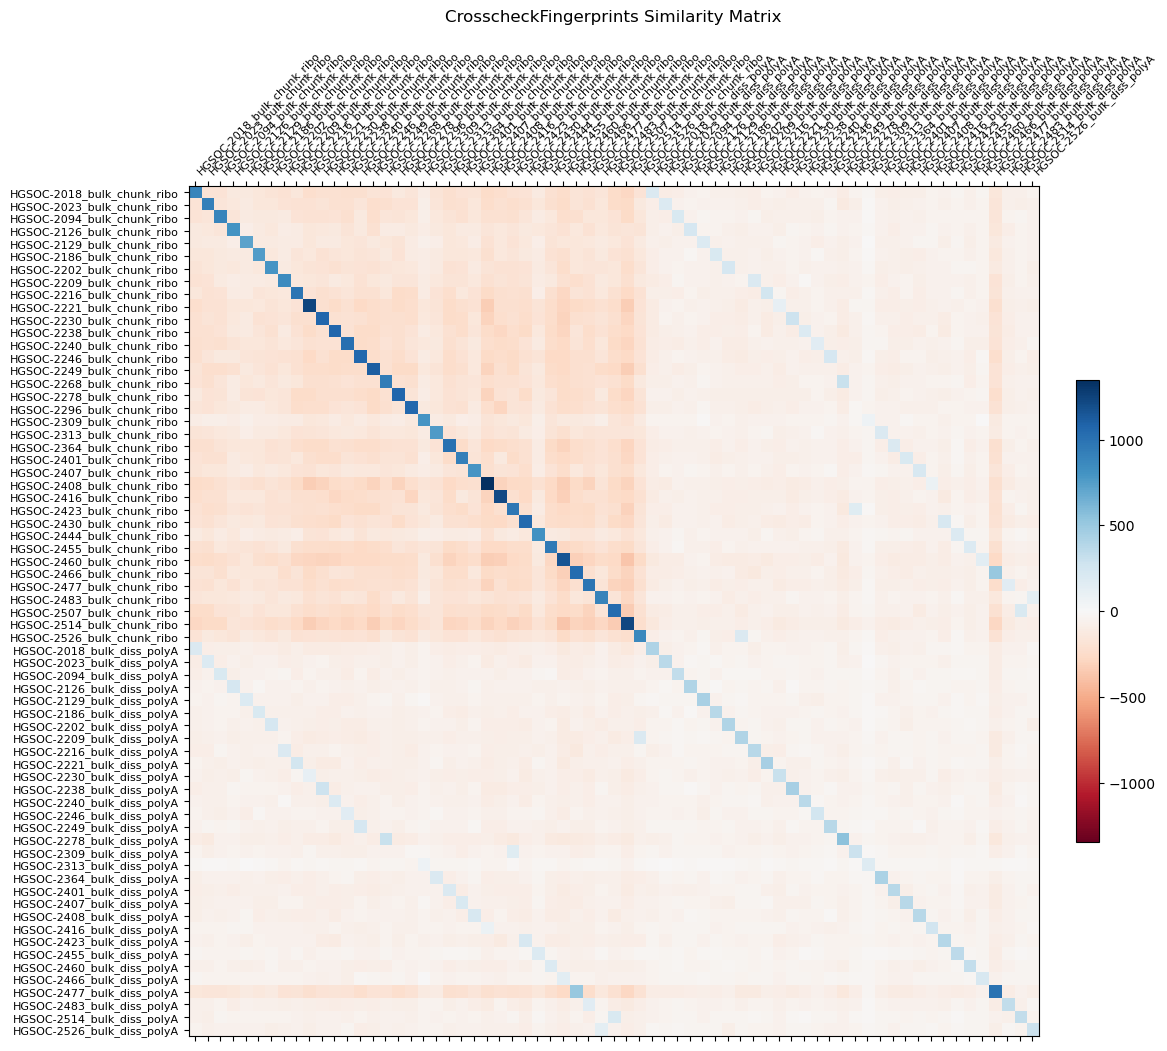

In [350]:
all_samples_matrix_viz(fingerprints_matrix, tool="CrosscheckFingerprints", dataset=dataset, save_fig=True)

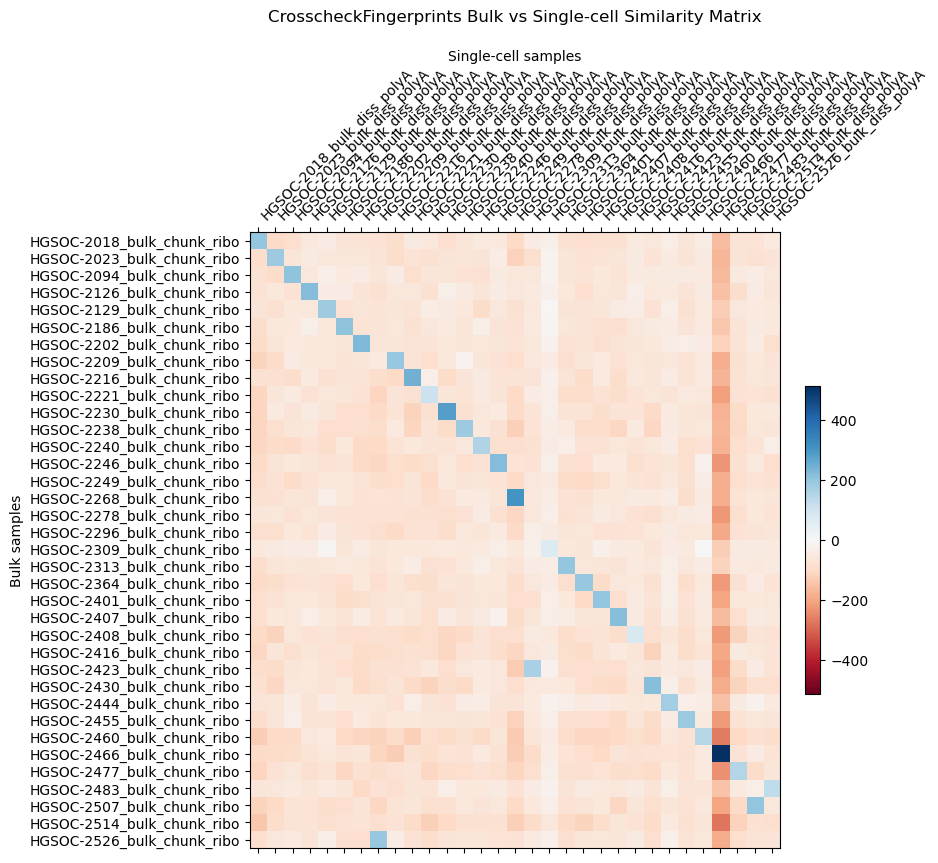

In [351]:
bulk_vs_singlecell_matrix_viz(fingerprints_matrix, tool="CrosscheckFingerprints", dataset=dataset, save_fig=True)

In [352]:
fingerprints_df["RESULT"].value_counts()

RESULT
EXPECTED_MISMATCH    4360
EXPECTED_MATCH         67
UNEXPECTED_MATCH       62
Name: count, dtype: int64

In [353]:
# Confirmed that the expected matches are simply the samples matching themselves
fingerprint_exp_matches = fingerprints_df[fingerprints_df["RESULT"]=="EXPECTED_MATCH"]
fingerprint_exp_matches[fingerprint_exp_matches["LEFT_SAMPLE"] != fingerprint_exp_matches["RIGHT_SAMPLE"]]

,LEFT_SAMPLE,RIGHT_SAMPLE,LOD_SCORE,RESULT


In [354]:
fingerprints_matches = fingerprints_df[fingerprints_df["RESULT"]=="UNEXPECTED_MATCH"]

In [355]:
# Out of 80 unexpected matches
# There should be really only 40 pairs since it's symmetric
#
# 5/40 are polyA vs polyA (and they all involve sample 2507)
# 0 are ribo vs ribo
# 35/40 are polyA vs ribo
fingerprints_matches[
    ~(fingerprints_matches["LEFT_SAMPLE"].str.contains("polyA") & fingerprints_matches["RIGHT_SAMPLE"].str.contains("polyA"))
].sort_values(
    by=["LEFT_SAMPLE", "RIGHT_SAMPLE"]
).drop_duplicates(
    "LOD_SCORE"
).reset_index(
    drop=True
)

,LEFT_SAMPLE,RIGHT_SAMPLE,LOD_SCORE,RESULT
0,HGSOC-2018_bulk_chunk_ribo,HGSOC-2018_bulk_diss_polyA,197.938691,UNEXPECTED_MATCH
1,HGSOC-2023_bulk_chunk_ribo,HGSOC-2023_bulk_diss_polyA,186.372326,UNEXPECTED_MATCH
2,HGSOC-2094_bulk_chunk_ribo,HGSOC-2094_bulk_diss_polyA,204.709169,UNEXPECTED_MATCH
3,HGSOC-2126_bulk_chunk_ribo,HGSOC-2126_bulk_diss_polyA,221.965748,UNEXPECTED_MATCH
4,HGSOC-2129_bulk_chunk_ribo,HGSOC-2129_bulk_diss_polyA,182.191976,UNEXPECTED_MATCH
5,HGSOC-2186_bulk_chunk_ribo,HGSOC-2186_bulk_diss_polyA,205.165566,UNEXPECTED_MATCH
6,HGSOC-2202_bulk_chunk_ribo,HGSOC-2202_bulk_diss_polyA,227.722145,UNEXPECTED_MATCH
7,HGSOC-2209_bulk_chunk_ribo,HGSOC-2216_bulk_diss_polyA,195.143683,UNEXPECTED_MATCH
8,HGSOC-2209_bulk_diss_polyA,HGSOC-2526_bulk_chunk_ribo,193.867424,UNEXPECTED_MATCH
9,HGSOC-2216_bulk_chunk_ribo,HGSOC-2221_bulk_diss_polyA,244.463959,UNEXPECTED_MATCH


# BAMixChecker

In [112]:
bamixchecker_df = pd.read_csv(DATA_PATH + f"bamixchecker/{dataset}/BAMixChecker/Total_result.txt", sep="\t", index_col=0, header=None)
bamixchecker_df.columns = ["Sample", "Concordance Rate", "Conclusion"]

In [113]:
bamixchecker_dict = {
    x: 
    # x.replace("_filtered_rg.bam", "") 
    re.sub(r"[a-zA-Z0-9]{32}_", "", x.replace("_filtered_rg.bam", "").replace(f"{dataset}/", "").replace("_filtered_variants.snps", "").replace("ds.", ""))
    for x in list(set(bamixchecker_df.index) | set(bamixchecker_df["Sample"]))
}
bamixchecker_df.index = bamixchecker_df.index.map(bamixchecker_dict)
bamixchecker_df["Sample"] = bamixchecker_df["Sample"].map(bamixchecker_dict)

In [114]:
bamixchecker_df.head()

,Sample,Concordance Rate,Conclusion
0,,,
HGSOC-2129_bulk_chunk_ribo,HGSOC-2202_bulk_chunk_ribo,0.0,Unmatched
HGSOC-2129_bulk_chunk_ribo,HGSOC-2209_bulk_chunk_ribo,0.0,Unmatched
HGSOC-2129_bulk_chunk_ribo,HGSOC-2407_bulk_chunk_ribo,0.0,Unmatched
HGSOC-2129_bulk_chunk_ribo,HGSOC-2526_bulk_chunk_ribo,0.0,Unmatched
HGSOC-2129_bulk_chunk_ribo,HGSOC-2309_bulk_chunk_ribo,0.0,Unmatched


In [115]:
def long_df_to_matrix_bamixchecker(df):
    matrix = pd.DataFrame()

    for x in list(df.index):
        for y in df["Sample"].values:
            corr_value = df.loc[(df.index == x) & (df["Sample"] == y), "Concordance Rate"]
            if not corr_value.empty:
                matrix.at[y, x] = corr_value.values[0]
                matrix.at[x, y] = corr_value.values[0]

    # Order rows and columns
    matrix = matrix[matrix.columns.sort_values()]
    matrix = matrix.reindex(sorted(matrix.index))

    return matrix

In [116]:
bamixchecker_matrix = long_df_to_matrix_bamixchecker(bamixchecker_df)

In [117]:
bamixchecker_matrix.head()

,HGSOC-2018_bulk_chunk_ribo,HGSOC-2018_bulk_diss_polyA,HGSOC-2023_bulk_chunk_ribo,HGSOC-2023_bulk_diss_polyA,HGSOC-2094_bulk_chunk_ribo,HGSOC-2094_bulk_diss_polyA,HGSOC-2126_bulk_chunk_ribo,HGSOC-2126_bulk_diss_polyA,HGSOC-2129_bulk_chunk_ribo,HGSOC-2129_bulk_diss_polyA,...,HGSOC-2477_bulk_chunk_ribo,HGSOC-2477_bulk_diss_polyA,HGSOC-2483_bulk_chunk_ribo,HGSOC-2483_bulk_diss_polyA,HGSOC-2507_bulk_chunk_ribo,HGSOC-2507_bulk_diss_polyA,HGSOC-2514_bulk_chunk_ribo,HGSOC-2514_bulk_diss_polyA,HGSOC-2526_bulk_chunk_ribo,HGSOC-2526_bulk_diss_polyA
HGSOC-2018_bulk_chunk_ribo,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HGSOC-2018_bulk_diss_polyA,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HGSOC-2023_bulk_chunk_ribo,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HGSOC-2023_bulk_diss_polyA,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HGSOC-2094_bulk_chunk_ribo,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


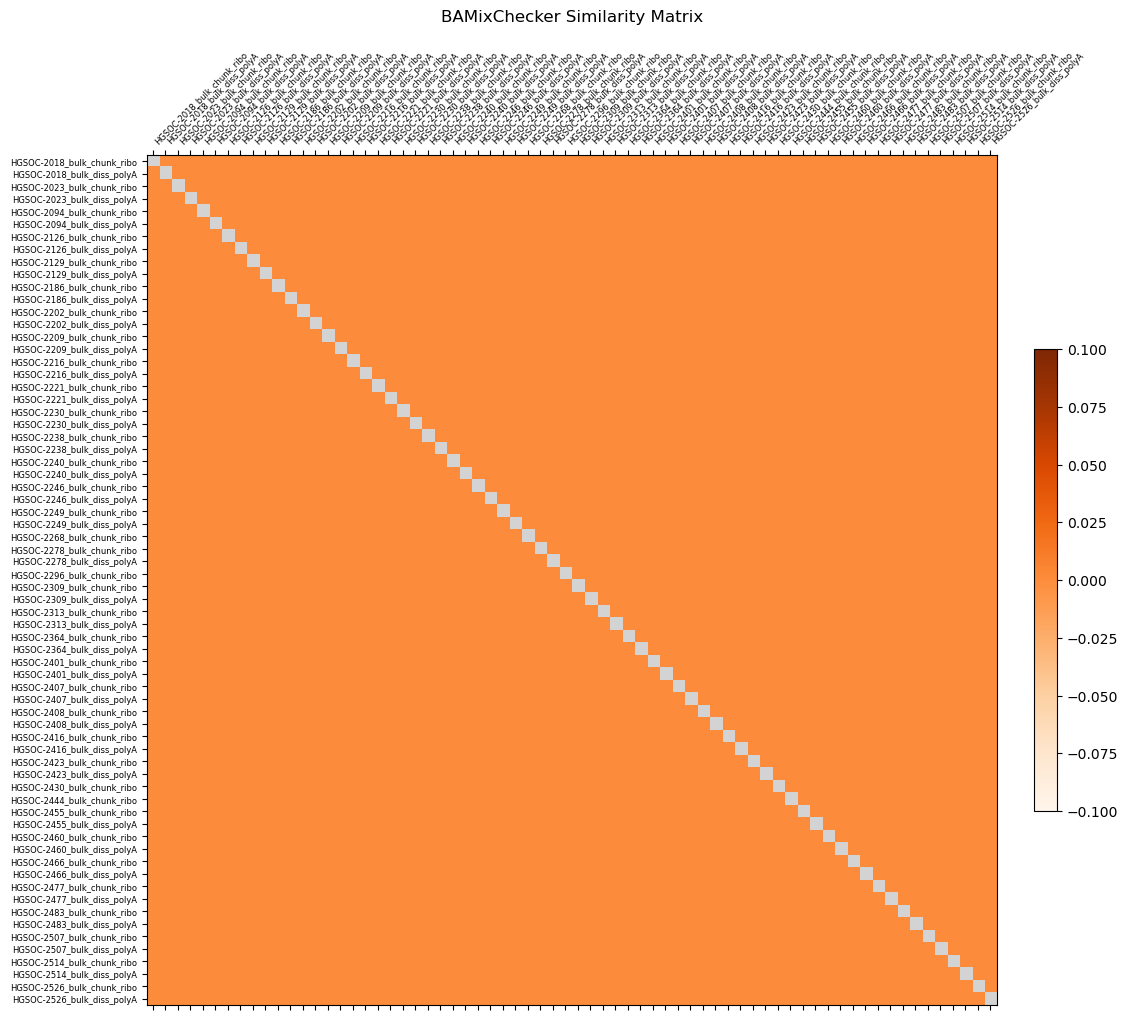

In [241]:
all_samples_matrix_viz(bamixchecker_matrix, tool="BAMixChecker", dataset=dataset, save_fig=True)

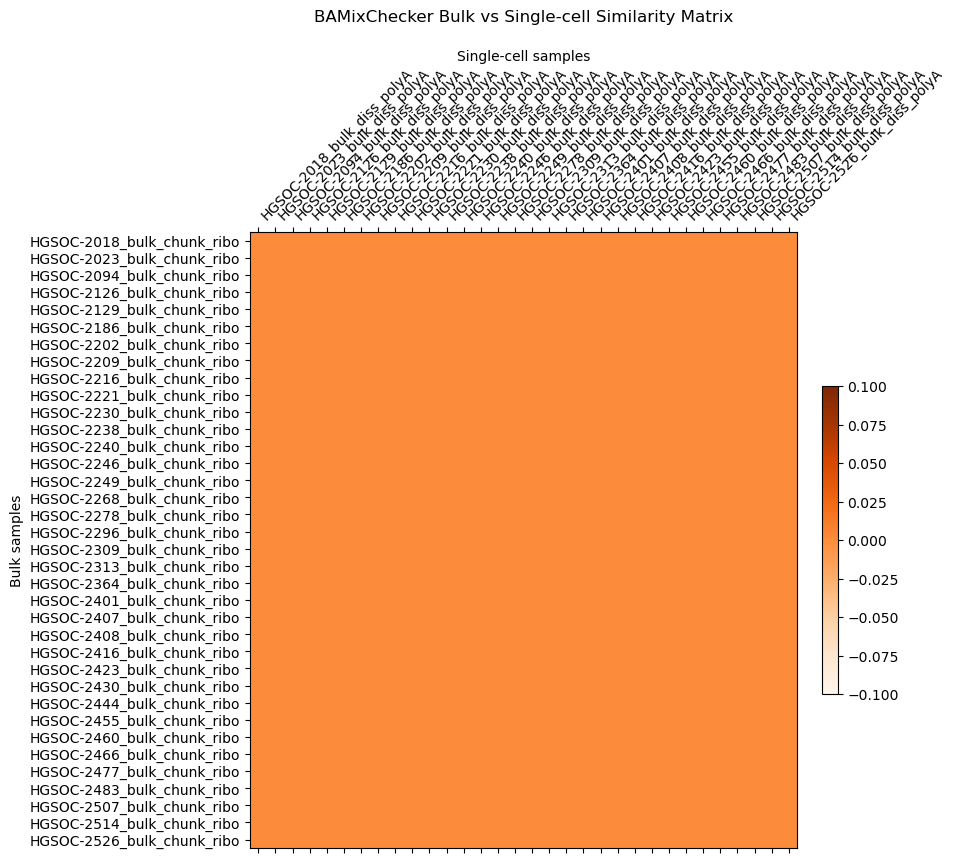

In [142]:
bulk_vs_singlecell_matrix_viz(bamixchecker_matrix, tool="BAMixChecker", dataset=dataset, save_fig=True)

# Tool comparison

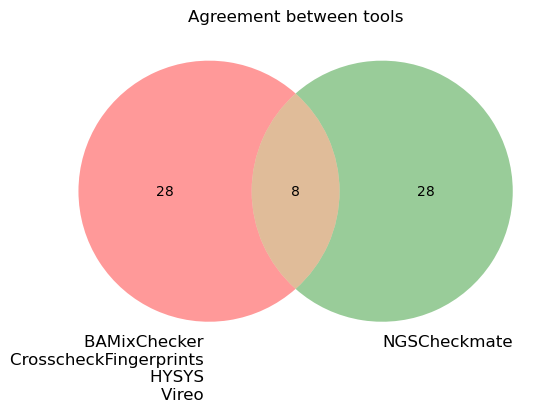

In [ ]:
venn2(subsets=(28, 28, 8), set_labels=('BAMixChecker \nCrosscheckFingerprints \nHYSYS \nVireo ', 'NGSCheckmate'))
plt.title("Agreement between tools")
# plt.savefig(FIGURES_PATH + f"{dataset}_tool_agreement_venn_diagram.png", bbox_inches="tight", dpi=300)
# plt.savefig(FIGURES_PATH + f"{dataset}_tool_agreement_venn_diagram.pdf", bbox_inches="tight", dpi=300